# Quick Start

In this comprehensive quick start, we will build a support chatbot in LangGraph across the next set of Jupyter Notebooks.

We'll start with a basic chatbot and progressively add more sophisticated capabilities, introducing key LangGraph concepts along the way.

## Setup

First, install the required packages:

In [ ]:
%pip install --quiet -U langchain langchain-openai langchain-community langchain-text-splitters langgraph langgraph-prebuilt langgraph-checkpoint-sqlite langsmith ddgs --upgrade

Next, set your API keys:

In [ ]:
import getpass
import os
import warnings

# Suppress deprecation warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="langchain")

# Set up your OpenAI client
if not os.getenv("OPENAI_API_KEY"):
    secret_key = getpass.getpass("Enter your OpenAI API key: ")
    os.environ["OPENAI_API_KEY"] = secret_key

## Build a Basic Chatbot

We'll first create a simple chatbot using LangGraph. This chatbot will respond directly to user messages. Though simple, it will illustrate the core concepts of building with LangGraph. By the end of this section, you will have a built rudimentary chatbot.

Start by creating a `StateGraph`. A `StateGraph` object defines the structure of our chatbot as a "state machine". We'll add `nodes` to represent the llm and functions our chatbot can call and `edges` to specify how the bot should transition between these functions.

In [3]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages

class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

**Notice** that we've defined our `State` as a TypedDict with a single key: `messages`. The `messages` key is annotated with the [`add_messages`](https://langchain-ai.github.io/langgraph/reference/graphs/?h=add+messages#add_messages) function, which tells LangGraph to append new messages to the existing list, rather than overwriting it.

So now our graph knows two things:

1. Every `node` we define will receive the current `State` as input and return a value that updates that state.
2. `messages` will be _appended_ to the current list, rather than directly overwritten. This is communicated via the prebuilt [`add_messages`](https://langchain-ai.github.io/langgraph/reference/graphs/?h=add+messages#add_messages) function in the `Annotated` syntax.

Next, add a "`chatbot`" node. Nodes represent units of work. They are typically regular python functions.

In [4]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI()

def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

# The first argument is the unique node name
# The second argument is the function or object that will be called whenever
# the node is used.
graph_builder.add_node("chatbot", chatbot)

**Notice** how the `chatbot` node function takes the current `State` as input and returns an updated `messages` list. This is the basic pattern for all LangGraph node functions.

The `add_messages` function in our `State` will append the llm's response messages to whatever messages are already in the state.

Next, add an `entry` point. This tells our graph **where to start its work** each time we run it.

In [5]:
graph_builder.set_entry_point("chatbot")

Similarly, set a `finish` point. This instructs the graph **"any time this node is run, you can exit."**

In [6]:
graph_builder.set_finish_point("chatbot")

Finally, we'll want to be able to run our graph. To do so, call "`compile()`" on the graph builder. This creates a "`CompiledGraph`" we can use invoke on our state.

In [7]:
graph = graph_builder.compile()

You can visualize the graph using the `get_graph` method and one of the "draw" methods, like `draw_ascii` or `draw_png`. The `draw` methods each require additional dependencies.

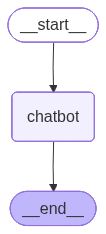

In [8]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

Now let's run the chatbot! 

**Tip:** You can exit the chat loop at any time by typing "quit", "exit", or "q".

In [9]:
sample_inputs = ["What are the core ideas behind LangGraph?"]

for user_input in sample_inputs:
    print("User:", user_input)
    for event in graph.stream({"messages": ("user", user_input)}):
        print(event['chatbot']['messages'])
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)


User: What are the core ideas behind LangGraph?
[AIMessage(content='LangGraph is a neural network architecture designed for natural language understanding tasks, particularly focused on sentence and document-level understanding. The core ideas behind LangGraph include:\n\n1. Graph-based representation: LangGraph represents language data as a graph, with words or tokens as nodes and their relationships as edges. This enables the model to capture complex dependencies and interactions between words in a sentence or document.\n\n2. Hierarchical structure: LangGraph has a hierarchical structure, with different layers of the network capturing different levels of linguistic information. This allows the model to learn representations at multiple levels of abstraction, from individual words to entire sentences.\n\n3. Attention mechanism: LangGraph uses an attention mechanism to selectively focus on relevant parts of the input data. This helps the model to effectively combine information from di

In [10]:
from langchain_core.messages import HumanMessage
graph.invoke({"messages": [HumanMessage(content="Hello, world!")]})

{'messages': [HumanMessage(content='Hello, world!', additional_kwargs={}, response_metadata={}, id='ac275169-5222-4e5e-9dc7-2b3f2c7d36fa'),
  AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 11, 'total_tokens': 20, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DKQmQ5UC9xmdn5ivlI2egnB8vd9Fs', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cfc72-4956-7023-b280-6816f34cea34-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 9, 'total_tokens': 20, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'a